In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy
from scipy.stats import pearsonr
from scipy.stats import bernoulli, beta, binom, lognorm, uniform
import math
from scipy.optimize import minimize
import random
import seaborn as sns
from scipy.stats import poisson
from scipy.stats import norm

In [2]:
# Load data

data_dir = os.path.join("data", "HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv")
gmt_data = pd.read_csv(data_dir, index_col = 'Time')
gmt_data['Anomaly (deg C)'] = gmt_data['Anomaly (deg C)'] - gmt_data.loc[1980:1999,:]['Anomaly (deg C)'].mean()
gmt_data.loc[1980:1999,:]['Anomaly (deg C)'].mean()
data_dir = os.path.join("data", "CSIRO_Recons_gmsl_yr_2015.csv")
gmsa_data = pd.read_csv(data_dir, index_col = 'Time')
# gmsa_data = pd.read_csv(data_dir)
gmsa_data.index = gmsa_data.index-0.5
gmsa_data['GMSL (mm)'] = gmsa_data['GMSL (mm)'] - gmsa_data.loc[1980:1999,:]['GMSL (mm)'].mean()
gmsa_data.loc[1980:1999,:]['GMSL (mm)'].mean()
gmt_data = gmt_data.drop(gmt_data.index.difference(gmsa_data.index))
len(gmt_data)

134

In [3]:
Seq = np.zeros(len(gmt_data))
def sim_gmsl(S_0, gmta_data, response_time, a, b):
    Seq = np.zeros(len(gmta_data))
    S = np.zeros(len(gmta_data))
    S[0] = S_0
        
    for i in range(0,len(gmta_data)-1):
        Seq[i] = a*gmta_data.iloc[i] + b
        S[i+1] = S[i] + (Seq[i]-S[i])/response_time
    
    return(S)
        

In [4]:
def gmsl_loglik(params, gmsl_data, gmta_data, gmsl_error):
    S_0, response_time, a, b, σ  = params  # unpack parameter vector
    y = sim_gmsl(S_0, gmta_data, response_time, a, b)
    ll = np.sum(norm.logpdf(gmsl_data, loc=y, scale=np.sqrt(σ**2+gmsl_error**2)))  # compute log-likelihood
    return ll

In [5]:
params = [1,1,1,1,1,0.5]
gmsl_data = gmsa_data['GMSL (mm)']
gmta_data = gmt_data['Anomaly (deg C)']
gmsl_error = gmsa_data['GMSL uncertainty (mm)']
S_0, response_time, a, b, σ, ρ  = params  # unpack parameter vector
gmsl_sim = sim_gmsl(S_0, gmta_data, response_time, a, b)
residuals = (gmsl_data - gmsl_sim).values


In [6]:
T = len(gmsl_data)
ll = 0  # initialize log-likelihood counter
for t in range(len(gmsl_error)):
    if t == 0:
        ll += norm.logpdf(residuals[0], loc=0, scale=np.sqrt(σ**2 / (1 - ρ**2) + gmsl_error.values[0]**2))
    else:
        resid_wn = residuals[t] - ρ * residuals[t-1]
        ll += norm.logpdf(resid_wn, loc=0, scale=np.sqrt(σ**2 + gmsl_error.values[t]**2))

In [7]:
def gmsl_loglik(params, gmsl_data, gmta_data, gmsl_error):
    S_0, response_time, a, b, σ, ρ  = params  # unpack parameter vector
    gmsl_sim = sim_gmsl(S_0, gmta_data, response_time, a, b)
    residuals = (gmsl_data - gmsl_sim).values
    # ll = np.sum(norm.logpdf(gmsl_data, loc=y, scale=np.sqrt(σ**2+gmsl_error**2)))  # compute log-likelihood
    T = len(gmsl_data)
    ll = 0  # initialize log-likelihood counter
    for t in range(len(gmsl_error)):
        if t == 0:
            ll += norm.logpdf(residuals[0], loc=0, scale=np.sqrt(σ**2 / (1 - ρ**2) + gmsl_error.values[0]**2))
        else:
            resid_wn = residuals[t] - ρ * residuals[t-1]
            ll += norm.logpdf(resid_wn, loc=0, scale=np.sqrt(σ**2 + gmsl_error.values[t]**2))

    return ll



In [8]:
lb = [-10000.0, 0.1, -1000.0,-1000.0,  0.01,  -0.9999]
ub = [0.0, 10000.0, 10000.0,1000.0,  1000.0,  0.9999]
p0 = [-160, 208.0, 1290.0, 770.0, 0.5, 0.5]

optim_out = minimize(lambda params: -gmsl_loglik(params, gmsa_data['GMSL (mm)'], gmt_data['Anomaly (deg C)'], gmsa_data['GMSL uncertainty (mm)']), p0, bounds=list(zip(lb, ub)))
p_mle = np.round(optim_out.x)

print(p_mle)
# θ_ar = optim_out.minimizer
θ_ar = optim_out.x

[-157.  147.  505.  345.    0.    1.]


In [15]:
optim_out.x

array([-1.57086862e+02,  1.46929664e+02,  5.04692254e+02,  3.45252806e+02,
        1.00000000e-02,  5.35064503e-01])

In [14]:
optim_out

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 454.102443257878
        x: [-1.571e+02  1.469e+02  5.047e+02  3.453e+02  1.000e-02
             5.351e-01]
      nit: 77
      jac: [ 7.901e-04 -1.313e-03 -2.785e-04  8.129e-04  1.028e-02
            -2.501e-03]
     nfev: 791
     njev: 113
 hess_inv: <6x6 LbfgsInvHessProduct with dtype=float64>

In [9]:
sim_out = sim_gmsl(p_mle[0], gmt_data['Anomaly (deg C)'], p_mle[1], p_mle[2], p_mle[3])
sim_out = pd.Series(data = sim_out, index = gmt_data.index)

In [10]:
n = 1000
# get iid and AR residuals from relevant processes
# residuals_iid = np.stack([np.random.normal(0, np.sqrt(temp_sd[i]**2 + θ_iid[-1]**2), n) for i in range(len(temp_sd))], axis=0)
residuals_ar = np.zeros((len(gmsl_error), n))
for t in range(len(gmsl_error)):
    if t == 0:
        residuals_ar[t, :] = np.random.normal(0, np.sqrt(θ_ar[-2]**2 / (1 - θ_ar[-1]**2) + gmsl_error.values[0]**2), n)
    else:
        residuals_ar[t, :] = θ_ar[-1] * residuals_ar[t-1, :] + np.random.normal(0, np.sqrt(θ_ar[-2]**2 + gmsl_error.values[t]**2), n)


<Axes: xlabel='Time'>

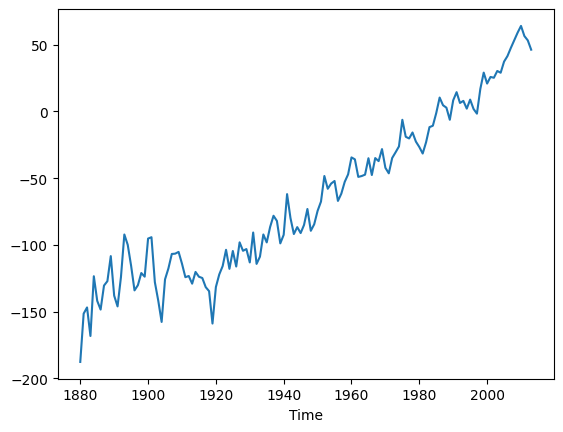

In [13]:
(sim_out + residuals_ar[:,1]).plot()